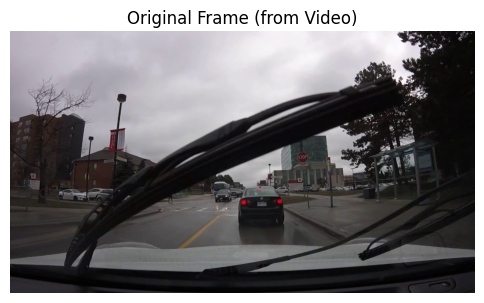

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Path to your video file
video_path = '/content/video_0015.mp4'

# Open video file
cap = cv2.VideoCapture(video_path)

# Read the first frame to display as example
ret, frame = cap.read()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(frame_rgb)
    plt.title('Original Frame (from Video)')
    plt.axis('off')
    plt.show()
else:
    print("Could not read video.")

cap.release()

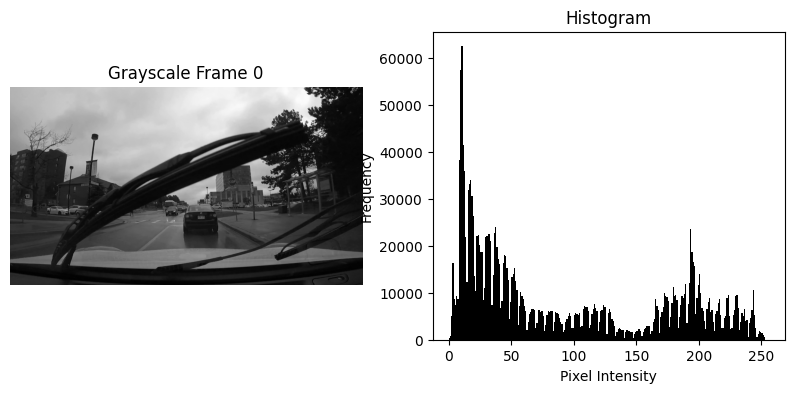

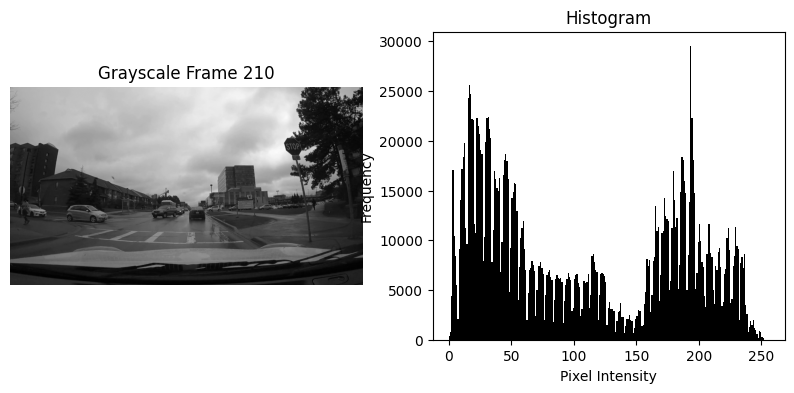

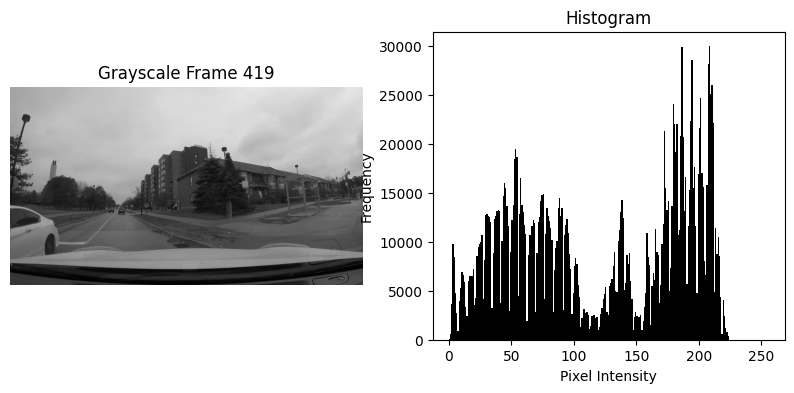

In [7]:
import cv2
import matplotlib.pyplot as plt

video_path = '/content/video_0015.mp4'
cap = cv2.VideoCapture(video_path)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
example_frames = [0, frame_count//2, frame_count-1]  # first, middle, last
gray_frames = []

for idx in range(frame_count):
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    if idx in example_frames:
        gray_frames.append((idx, gray))
cap.release()

# Display grayscale images and histograms for selected frames
for idx, gray_img in gray_frames:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(gray_img, cmap='gray')
    plt.title(f'Grayscale Frame {idx}')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.hist(gray_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title('Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.show()

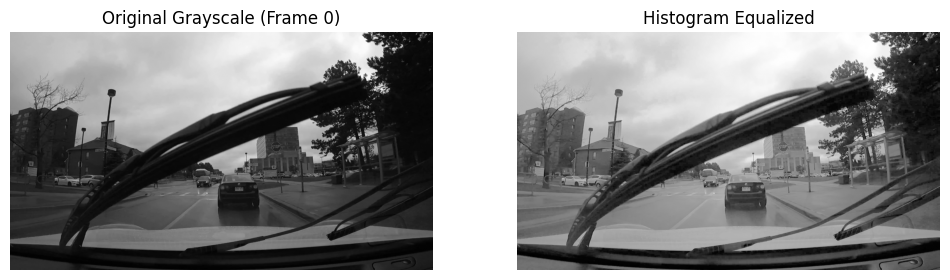

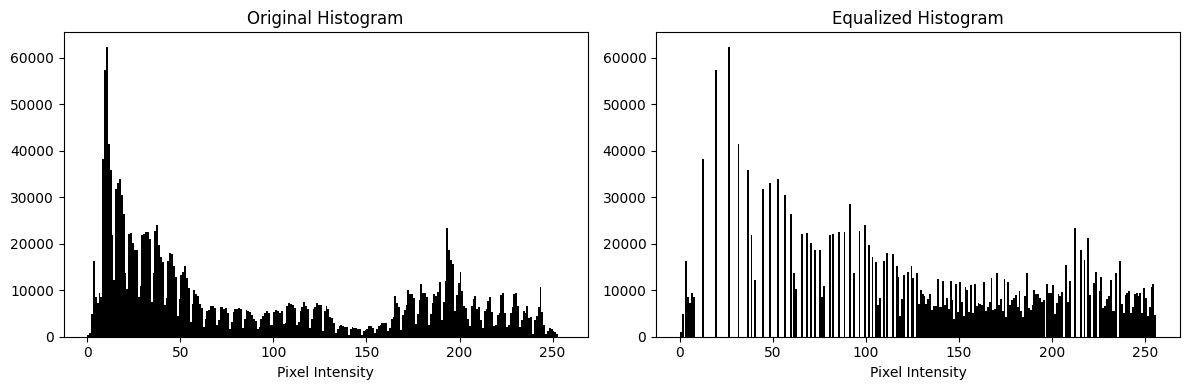

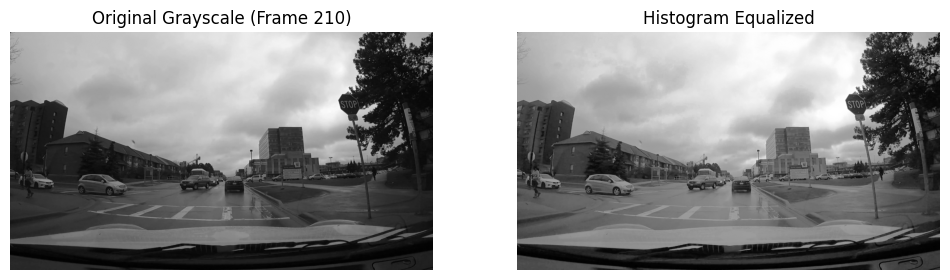

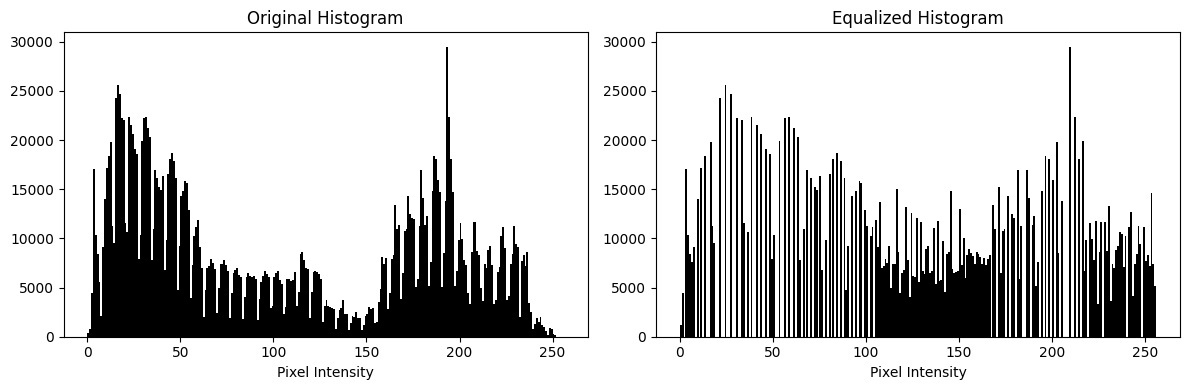

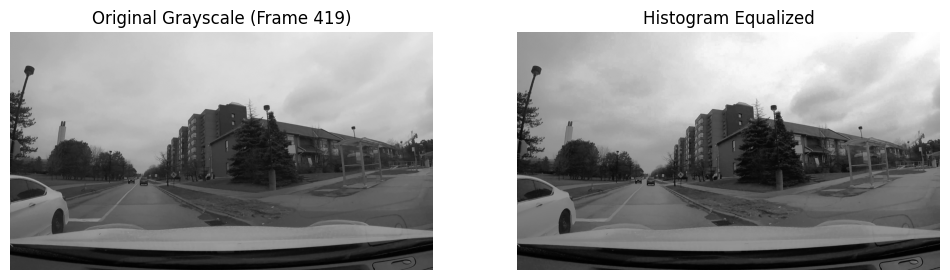

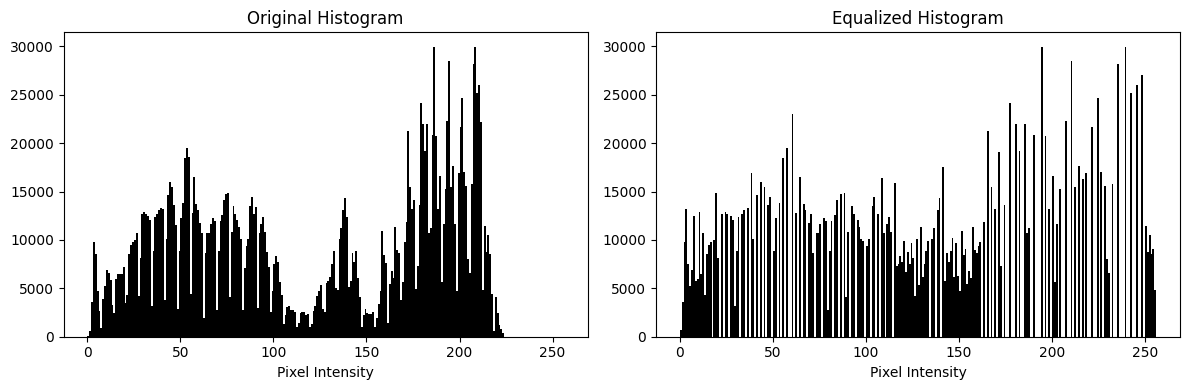

In [8]:
for idx, gray_img in gray_frames:
    # Apply histogram equalization
    equalized_img = cv2.equalizeHist(gray_img)

    # Display original and equalized images side by side
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(gray_img, cmap='gray')
    plt.title(f'Original Grayscale (Frame {idx})')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(equalized_img, cmap='gray')
    plt.title('Histogram Equalized')
    plt.axis('off')
    plt.show()

    # Display histograms
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(gray_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title('Original Histogram')
    plt.xlabel('Pixel Intensity')

    plt.subplot(1, 2, 2)
    plt.hist(equalized_img.ravel(), bins=256, range=[0, 256], color='black')
    plt.title('Equalized Histogram')
    plt.xlabel('Pixel Intensity')
    plt.tight_layout()
    plt.show()

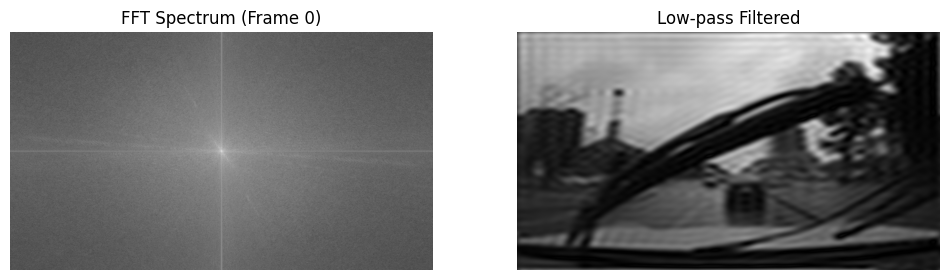

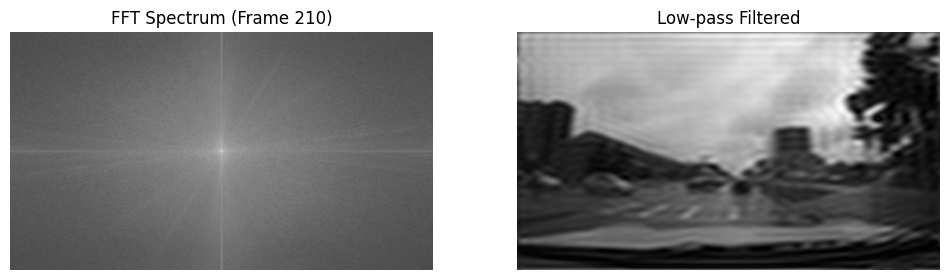

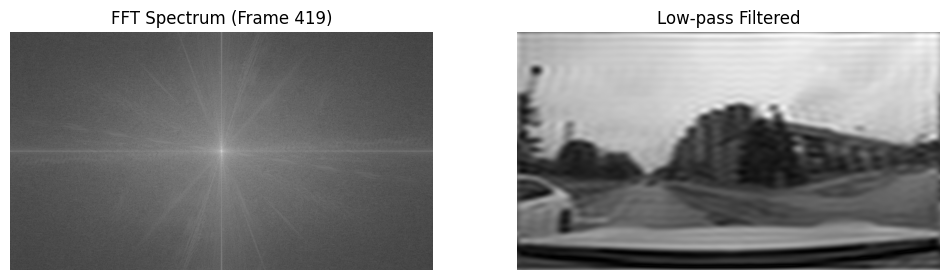

In [9]:
for idx, gray_img in gray_frames:
    # FFT
    f = np.fft.fft2(gray_img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

    # Low-pass filter mask
    rows, cols = gray_img.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    mask[crow-30:crow+30, ccol-30:ccol+30] = 1

    # Filter and inverse FFT
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    # Show magnitude spectrum and filtered image
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title(f'FFT Spectrum (Frame {idx})')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(img_back, cmap='gray')
    plt.title('Low-pass Filtered')
    plt.axis('off')
    plt.show()

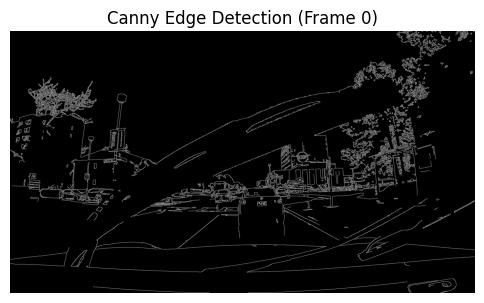

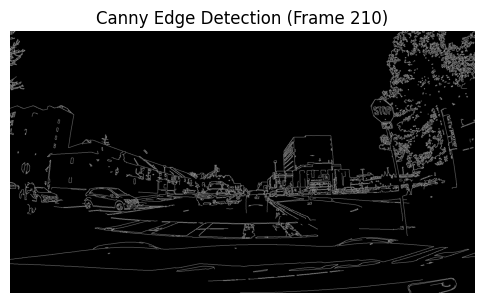

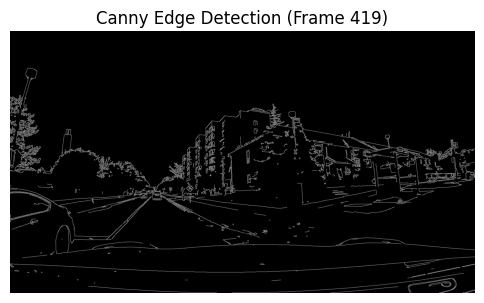

In [10]:
for idx, gray_img in gray_frames:
    edges_canny = cv2.Canny(gray_img, threshold1=50, threshold2=150)

    plt.figure(figsize=(6, 6))
    plt.imshow(edges_canny, cmap='gray')
    plt.title(f'Canny Edge Detection (Frame {idx})')
    plt.axis('off')
    plt.show()

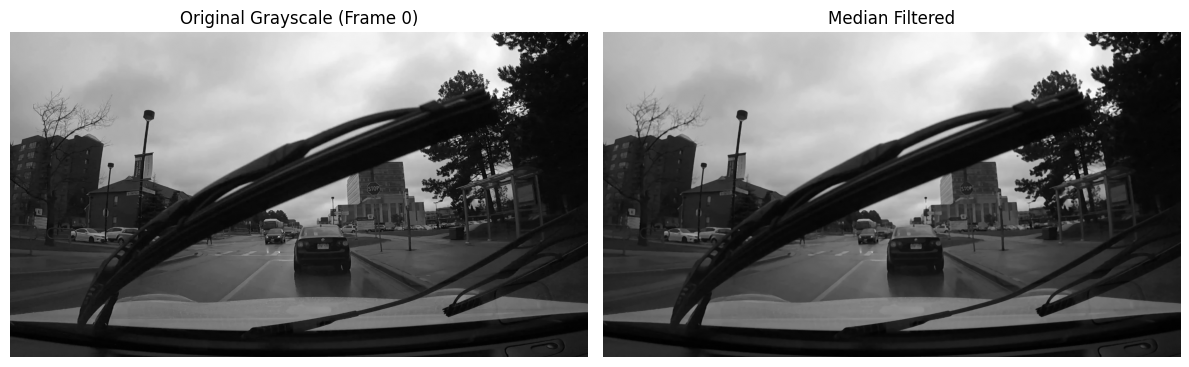

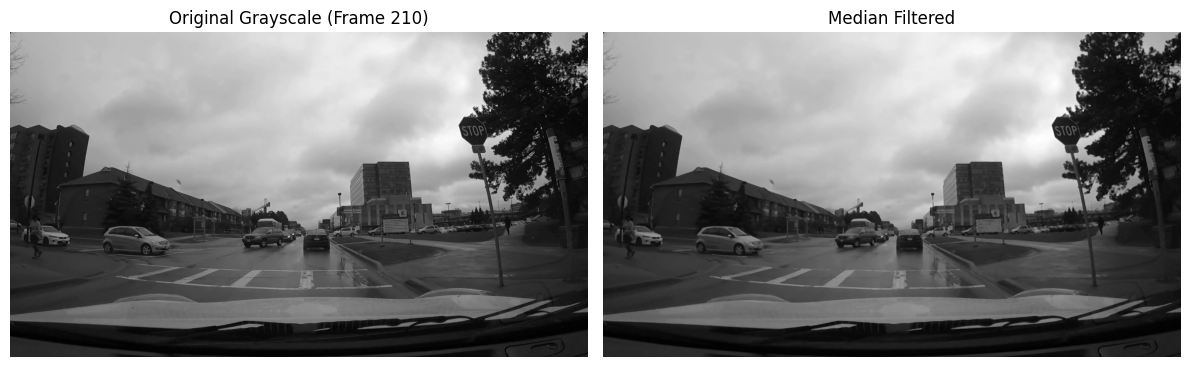

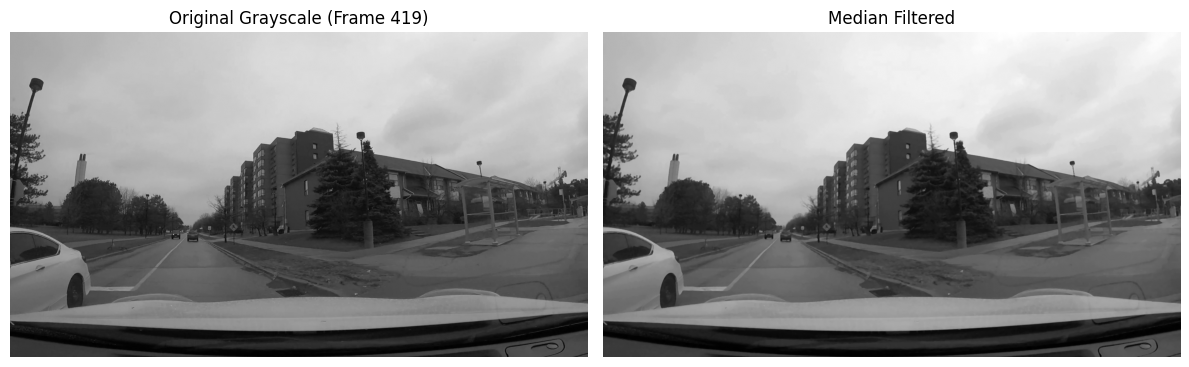

In [11]:
for idx, gray_img in gray_frames:
    median_filtered = cv2.medianBlur(gray_img, ksize=5)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(gray_img, cmap='gray')
    plt.title(f'Original Grayscale (Frame {idx})')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(median_filtered, cmap='gray')
    plt.title('Median Filtered')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [12]:
import cv2
import numpy as np

# Set paths
video_path = '/content/video_0015.mp4'
output_path = '/content/processed_output.mp4'

# Open video file for reading
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Output video writer (single-channel/grayscale output)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height), isColor=False)

# Choose some frames to display for your report
example_indices = [0, frame_count//2, frame_count-1]
example_results = []

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 1. Convert to Grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 2. Histogram Equalization
    equalized = cv2.equalizeHist(gray)

    # 3. FFT + Low-pass Filtering
    f = np.fft.fft2(equalized)
    fshift = np.fft.fftshift(f)
    mask = np.zeros_like(equalized, np.uint8)
    rows, cols = equalized.shape
    crow, ccol = rows // 2, cols // 2
    mask[crow-30:crow+30, ccol-30:ccol+30] = 1
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.abs(np.fft.ifft2(f_ishift)).astype(np.uint8)

    # 4. Edge Detection (Canny)
    edges = cv2.Canny(img_back, 50, 150)

    # 5. Median Filtering
    median_filtered = cv2.medianBlur(edges, 5)

    # Write processed frame to output video (show lanes & object boundaries)
    out.write(median_filtered)

    # Collect results for visualization if this is a selected frame
    if frame_idx in example_indices:
        example_results.append({
            'idx': frame_idx,
            'gray': gray,
            'equalized': equalized,
            'fft': img_back,
            'edges': edges,
            'filtered': median_filtered
        })

    frame_idx += 1

cap.release()
out.release()
print(f"Processing complete! Output saved to {output_path}")

Processing complete! Output saved to /content/processed_output.mp4
